In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf

data_dir = '/content/drive/MyDrive/data'
train_dir= os.path.join(data_dir, 'train')
test_dir= os.path.join(data_dir, 'test')

Mounted at /content/drive


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'

)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator= train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
test_generator= test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 493 images belonging to 2 classes.
Found 132 images belonging to 2 classes.


Classes détectées : {'benign': 0, 'malignant': 1}


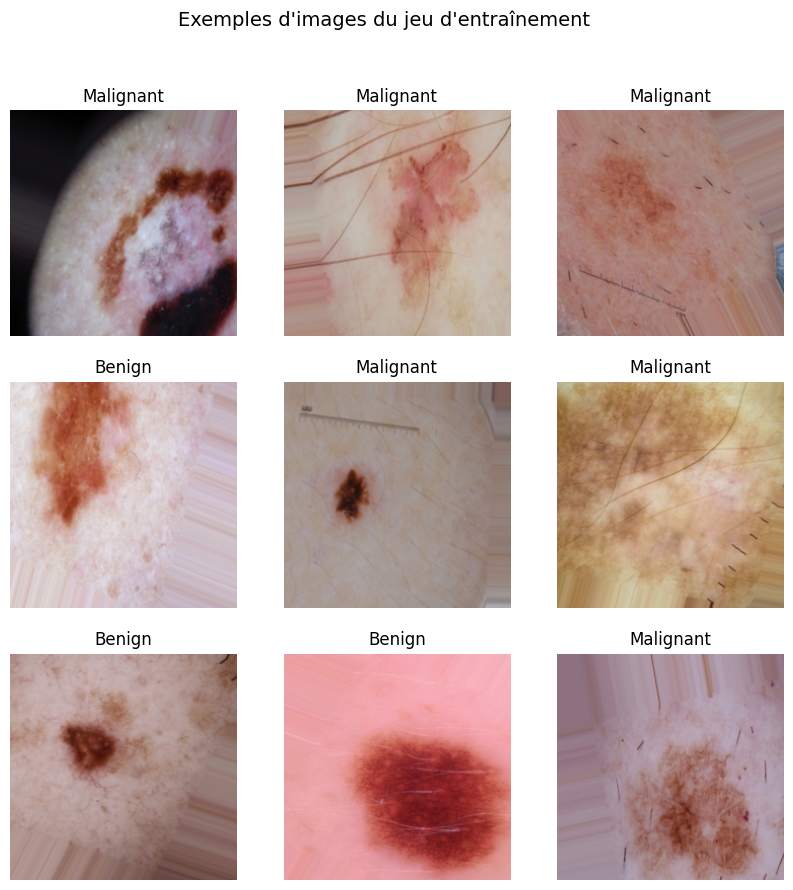

In [3]:
print("Classes détectées :", train_generator.class_indices)

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])

    label = "Malignant" if y_batch[i] == 1 else "Benign"
    plt.title(label)
    plt.axis('off')

plt.suptitle("Exemples d'images du jeu d'entraînement", fontsize=14)

plt.show()

In [4]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layers in base_model.layers:
  layers.trainable = False

x = Flatten()(base_model.output)
x = Dense(255, activation='relu')(x)
x= Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 255)            │     6,397,695 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 255)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,112,639 (80.54 MB)

 Trainable params: 6,397,951 (24.41 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
history= model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).ravel()
y_true= test_generator.classes
print("classification report : ")
print(classification_report(y_true, y_pred,target_names=['Benign','Malignant']))

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 126s 7s/step - accuracy: 0.6085 - loss: 0.6905 - val_accuracy: 0.7652 - val_loss: 0.5179
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 670ms/step - accuracy: 0.8093 - loss: 0.4782 - val_accuracy: 0.7576 - val_loss: 0.4790
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 585ms/step - accuracy: 0.8093 - loss: 0.4564 - val_accuracy: 0.7424 - val_loss: 0.4957
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 565ms/step - accuracy: 0.8093 - loss: 0.4209 - val_accuracy: 0.7121 - val_loss: 0.5621
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 670ms/step - accuracy: 0.7890 - loss: 0.4279 - val_accuracy: 0.7500 - val_loss: 0.4808
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 658ms/step - accuracy: 0.8296 - loss: 0.3899 - val_accuracy: 0.7500 - val_loss: 0.4870
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 567ms/step - accuracy: 0.8134 - loss: 0.4137 - val_accuracy: 0.7727 - val_loss: 0.4514
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 675ms/step - accuracy: 0.8438 - loss: 0.3750 - val_accuracy

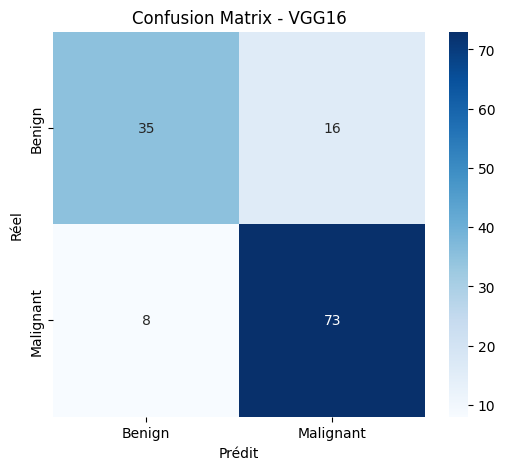

In [6]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Benign','Malignant'],yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix - VGG16')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

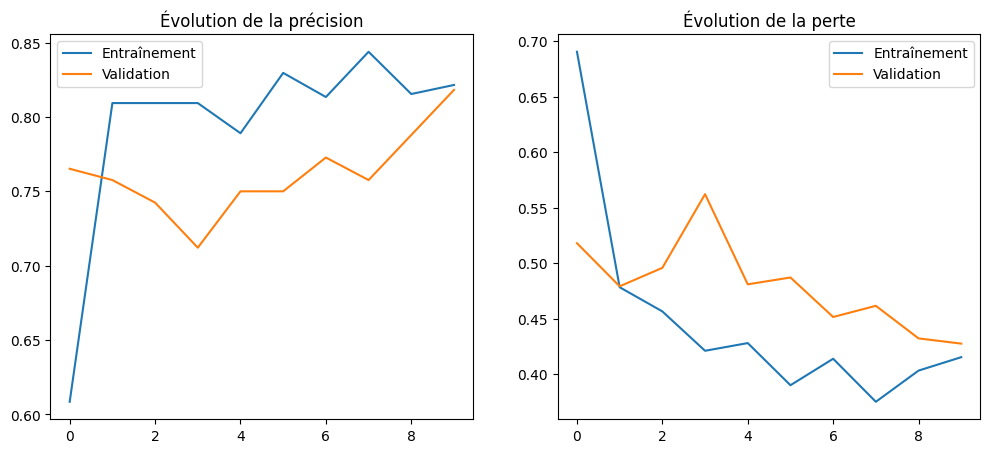

Modèle sauvegardé avec succès : /content/drive/MyDrive/vgg16_malignant_vs_benign.h5


In [7]:
# =========================
# 1. Courbes d’apprentissage
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Évolution de la précision")

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Évolution de la perte")

plt.show()

# =========================
# 2. Sauvegarde du modèle
# =========================
model_path = "/content/drive/MyDrive/vgg16_malignant_vs_benign.h5"
model.save(model_path)
print(f"Modèle sauvegardé avec succès : {model_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


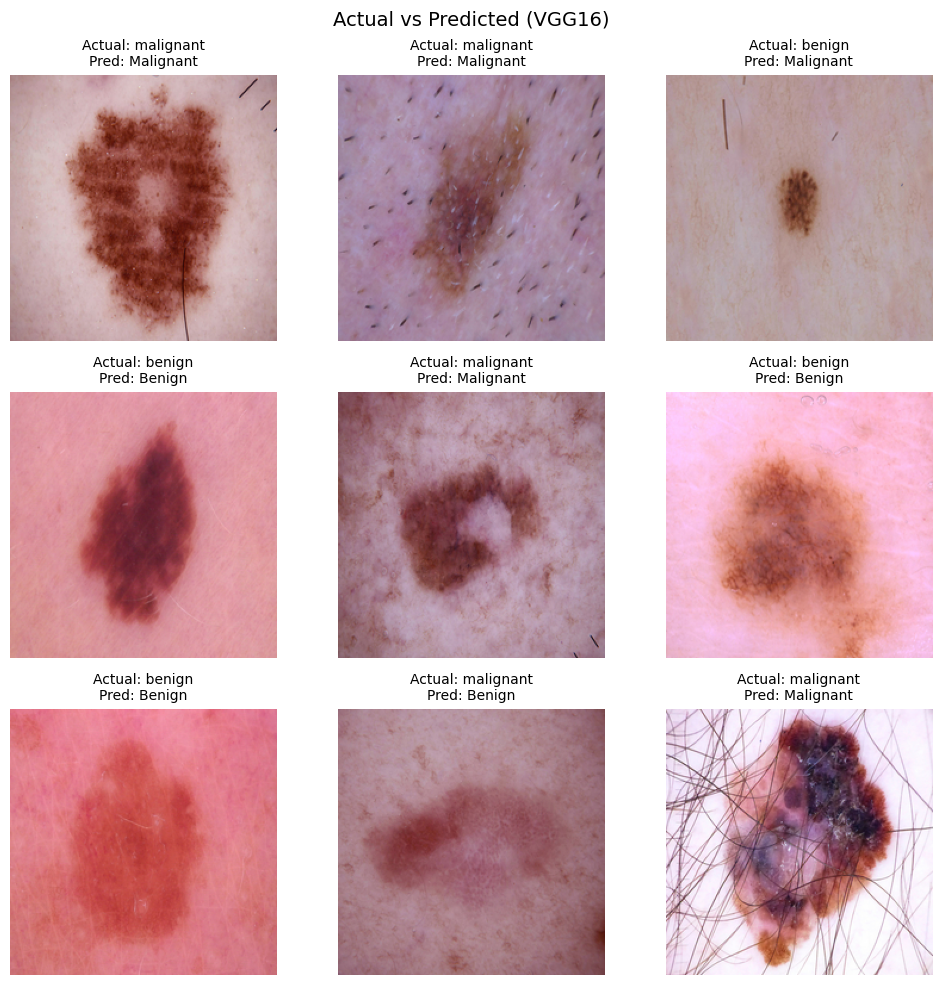

In [8]:
# ==========================================
# 3. Récupération des fichiers et classes
# ===============================import random
import random

filenames = test_generator.filenames
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Sélection aléatoire de 9 images
sample_indices = random.sample(range(len(filenames)), 9)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(sample_indices):
    img_path = os.path.join(test_dir, filenames[idx])

    # Chargement et prétraitement
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prédiction
    prediction = model.predict(img_array)
    predicted_label = "Malignant" if prediction > 0.5 else "Benign"
    actual_label = class_labels[true_classes[idx]]

    # Affichage
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}", fontsize=10)
    plt.axis("off")

plt.suptitle("Actual vs Predicted (VGG16)", fontsize=14)
plt.tight_layout()
plt.show()